##DATA PREPROCESSING
The dataset will be prepared for machine learning through data inspection, cleaning, transformation, feature engineering, and feature selection. The preprocessing procedure will ensure that the dataset is suitable for training and evaluating the Random Forest classification model.

In [ ]:
# Import required libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

import matplotlib.pyplot as plt

In [ ]:
# Load the dataset

df = pd.read_csv("/content/dataset1.csv")

# Display the first five records
df.head()

,index,having_IPhaving_IP_Address,URLURL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,1,-1,1,1,1,-1,-1,-1,-1,-1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,2,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,3,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,4,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,5,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1


##Dataset Inspection
The dataset will be examined to determine its dimensions, column names, data types, and general structure before preprocessing.

In [ ]:
# Display dataset dimensions

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

# Display data types
print("\nData Types:")
print(df.dtypes)

Number of rows: 11055
Number of columns: 32

Column Names:
['index ', 'having_IPhaving_IP_Address ', 'URLURL_Length ', 'Shortining_Service ', 'having_At_Symbol ', 'double_slash_redirecting ', 'Prefix_Suffix ', 'having_Sub_Domain ', 'SSLfinal_State ', 'Domain_registeration_length ', 'Favicon ', 'port ', 'HTTPS_token ', 'Request_URL ', 'URL_of_Anchor ', 'Links_in_tags ', 'SFH ', 'Submitting_to_email ', 'Abnormal_URL ', 'Redirect ', 'on_mouseover ', 'RightClick ', 'popUpWidnow ', 'Iframe ', 'age_of_domain ', 'DNSRecord ', 'web_traffic ', 'Page_Rank ', 'Google_Index ', 'Links_pointing_to_page ', 'Statistical_report ', 'Result']

Data Types:
index                           int64
having_IPhaving_IP_Address      int64
URLURL_Length                   int64
Shortining_Service              int64
having_At_Symbol                int64
double_slash_redirecting        int64
Prefix_Suffix                   int64
having_Sub_Domain               int64
SSLfinal_State                  int64
Domain_regist

##Cleaning Column Names
The column names will be standardized by removing unnecessary leading and trailing spaces. This will make the dataset easier to reference during preprocessing and model development.

In [ ]:
# Remove leading and trailing spaces from column names

df.columns = df.columns.str.strip()

# Display cleaned column names
print(df.columns.tolist())

['index', 'having_IPhaving_IP_Address', 'URLURL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report', 'Result']


##Checking Missing Values
Missing values will be identified to determine whether data imputation or removal is necessary.

In [ ]:
# Check missing values

missing_values = df.isnull().sum()

print(missing_values)

print("\nTotal missing values:", df.isnull().sum().sum())

index                          0
having_IPhaving_IP_Address     0
URLURL_Length                  0
Shortining_Service             0
having_At_Symbol               0
double_slash_redirecting       0
Prefix_Suffix                  0
having_Sub_Domain              0
SSLfinal_State                 0
Domain_registeration_length    0
Favicon                        0
port                           0
HTTPS_token                    0
Request_URL                    0
URL_of_Anchor                  0
Links_in_tags                  0
SFH                            0
Submitting_to_email            0
Abnormal_URL                   0
Redirect                       0
on_mouseover                   0
RightClick                     0
popUpWidnow                    0
Iframe                         0
age_of_domain                  0
DNSRecord                      0
web_traffic                    0
Page_Rank                      0
Google_Index                   0
Links_pointing_to_page         0
Statistica

##Checking Duplicate Records
Duplicate records will be identified and removed if present to prevent repeated observations from affecting the machine learning model.

In [ ]:
# Count duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [ ]:
# Remove duplicate records

df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (11055, 32)


##Target Variable
The Result column will be used as the target variable. It represents the classification of each website as either legitimate or phishing.

In [ ]:
# Check target variable

print(df["Result"].value_counts())

print("\nTarget percentages:")
print(df["Result"].value_counts(normalize=True) * 100)

Result
 1    6157
-1    4898
Name: count, dtype: int64

Target percentages:
Result
 1    55.694256
-1    44.305744
Name: proportion, dtype: float64


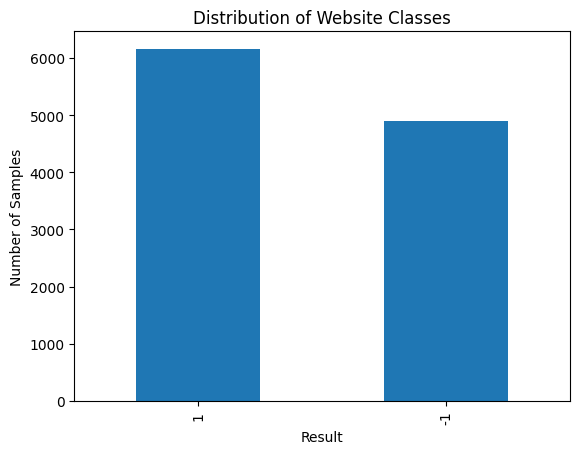

In [ ]:
# Visualize target distribution

df["Result"].value_counts().plot(kind="bar")

plt.title("Distribution of Website Classes")
plt.xlabel("Result")
plt.ylabel("Number of Samples")
plt.show()

##Removing the Index
The index column will be removed because it serves only as a record identifier and does not represent a meaningful characteristic of a website.

In [ ]:
# Remove index column

df = df.drop(columns=["index"])

print("Dataset shape after removing index:", df.shape)

Dataset shape after removing index: (11055, 31)


##Feature and Target Separation
The dataset will be divided into predictor variables (X) and the target variable (y). The 30 website and URL characteristics will be used as input features, while Result will serve as the classification target.

In [ ]:
# Separate features and target

X = df.drop(columns=["Result"])
y = df["Result"]

print("Number of features:", X.shape[1])
print("Target variable:", y.name)

Number of features: 30
Target variable: Result


##Data Transformation
The selected dataset already represents its website and URL characteristics using numerical values. Therefore, categorical encoding and feature scaling are not required for the Random Forest algorithm. The numerical representations will be retained for model training.

In [ ]:
# Check unique values for each feature

for column in X.columns:
    print(column, ":", sorted(X[column].unique()))

having_IPhaving_IP_Address : [np.int64(-1), np.int64(1)]
URLURL_Length : [np.int64(-1), np.int64(0), np.int64(1)]
Shortining_Service : [np.int64(-1), np.int64(1)]
having_At_Symbol : [np.int64(-1), np.int64(1)]
double_slash_redirecting : [np.int64(-1), np.int64(1)]
Prefix_Suffix : [np.int64(-1), np.int64(1)]
having_Sub_Domain : [np.int64(-1), np.int64(0), np.int64(1)]
SSLfinal_State : [np.int64(-1), np.int64(0), np.int64(1)]
Domain_registeration_length : [np.int64(-1), np.int64(1)]
Favicon : [np.int64(-1), np.int64(1)]
port : [np.int64(-1), np.int64(1)]
HTTPS_token : [np.int64(-1), np.int64(1)]
Request_URL : [np.int64(-1), np.int64(1)]
URL_of_Anchor : [np.int64(-1), np.int64(0), np.int64(1)]
Links_in_tags : [np.int64(-1), np.int64(0), np.int64(1)]
SFH : [np.int64(-1), np.int64(0), np.int64(1)]
Submitting_to_email : [np.int64(-1), np.int64(1)]
Abnormal_URL : [np.int64(-1), np.int64(1)]
Redirect : [np.int64(0), np.int64(1)]
on_mouseover : [np.int64(-1), np.int64(1)]
RightClick : [np.int64

## Feature Engineering
Feature engineering will be performed by creating aggregate indicators from the existing website and URL characteristics. The number of negative (-1) and suspicious (0) feature values for each website will be calculated as additional features. These derived variables provide an overall representation of the number of potentially suspicious indicators present in each sample.

In [ ]:
# Create copies so the original features remain unchanged

X_engineered = X.copy()

# Count the number of -1 indicators
X_engineered["negative_indicator_count"] = (X == -1).sum(axis=1)

# Count the number of 0 indicators
X_engineered["zero_indicator_count"] = (X == 0).sum(axis=1)

# Display the new features
X_engineered[[
    "negative_indicator_count",
    "zero_indicator_count"
]].head()

,negative_indicator_count,zero_indicator_count
0,16,1
1,8,4
2,12,4
3,10,4
4,9,5


In [ ]:
print("Original number of features:", X.shape[1])
print("Number of features after engineering:", X_engineered.shape[1])

Original number of features: 30
Number of features after engineering: 32


##Training and Testing Data
The prepared dataset will be divided into training and testing subsets. An 80:20 ratio will be used, where 80% of the data will be used for model training and 20% will be reserved for testing. Stratification will be applied to maintain the proportion of legitimate and phishing websites in both subsets.

In [ ]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X_engineered,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 8844
Testing samples: 2211


##Feature Selection
Feature selection will be performed using Random Forest feature importance. The training dataset will be used to identify the characteristics that contribute most to the classification of phishing and legitimate websites.

In [ ]:
# Train a Random Forest for feature importance

rf_selector = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_selector.fit(X_train, y_train)

# Get feature importance
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_selector.feature_importances_
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
7,SSLfinal_State,0.284911
13,URL_of_Anchor,0.221428
30,negative_indicator_count,0.084934
25,web_traffic,0.062985
6,having_Sub_Domain,0.054442
5,Prefix_Suffix,0.042370
14,Links_in_tags,0.037224
31,zero_indicator_count,0.027911
12,Request_URL,0.017931
28,Links_pointing_to_page,0.015868


In [ ]:
# Display top 15 most important features

top_features = feature_importance.head(15)

print(top_features)

                        Feature  Importance
7                SSLfinal_State    0.284911
13                URL_of_Anchor    0.221428
30     negative_indicator_count    0.084934
25                  web_traffic    0.062985
6             having_Sub_Domain    0.054442
5                 Prefix_Suffix    0.042370
14                Links_in_tags    0.037224
31         zero_indicator_count    0.027911
12                  Request_URL    0.017931
28       Links_pointing_to_page    0.015868
15                          SFH    0.015041
8   Domain_registeration_length    0.014429
23                age_of_domain    0.012508
24                    DNSRecord    0.011019
0    having_IPhaving_IP_Address    0.010652


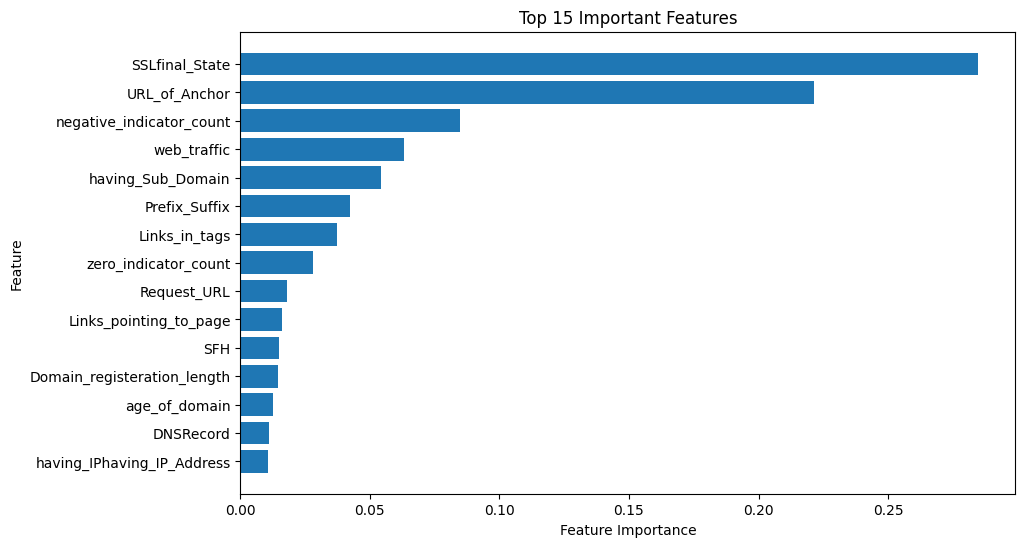

In [ ]:
# Plot top 15 features

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Important Features")
plt.show()

##15. Select Relevant Features

In [ ]:
# Select features with importance greater than or equal to the median

threshold = feature_importance["Importance"].median()

selected_features = feature_importance[
    feature_importance["Importance"] >= threshold
]["Feature"].tolist()

print("Selected features:")
print(selected_features)

print("\nNumber of selected features:", len(selected_features))

Selected features:
['SSLfinal_State', 'URL_of_Anchor', 'negative_indicator_count', 'web_traffic', 'having_Sub_Domain', 'Prefix_Suffix', 'Links_in_tags', 'zero_indicator_count', 'Request_URL', 'Links_pointing_to_page', 'SFH', 'Domain_registeration_length', 'age_of_domain', 'DNSRecord', 'having_IPhaving_IP_Address', 'Google_Index']

Number of selected features: 16


In [ ]:
# Create final datasets using selected features

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

print("Final training shape:", X_train_selected.shape)
print("Final testing shape:", X_test_selected.shape)

Final training shape: (8844, 16)
Final testing shape: (2211, 16)


##Saving the Preprocessed Dataset
The processed dataset will be saved as a CSV file for documentation and future model development.

In [ ]:
# Combine selected features and target

processed_df = X_engineered[selected_features].copy()
processed_df["Result"] = y.values

# Save processed dataset

processed_df.to_csv(
    "processed_phishing_dataset.csv",
    index=False
)

print("Processed dataset saved successfully.")

Processed dataset saved successfully.


In [ ]:
from google.colab import files

files.download("processed_phishing_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## RANDOM FOREST CLASSIFICATION — INITIAL BASELINE

This initial 100-tree Random Forest run serves as the baseline configuration. The later **Model Experimentation and Configuration Comparison** section performs the required second configuration, 5-fold cross-validation, and hyperparameter tuning.

For this dataset, `Result = -1` represents phishing and `Result = 1` represents legitimate websites.

In [ ]:
# Create the final Random Forest Classifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("Random Forest model created successfully.")


##Model Training

The Random Forest model will be trained using the selected features from the training dataset. Each decision tree learns patterns from the training data, and the trees' predictions are combined to determine the final classification.


In [ ]:
# Train the Random Forest model

rf_model.fit(X_train_selected, y_train)

print("Random Forest model training completed successfully.")


##Model Prediction

The trained Random Forest model will be used to predict the classes of the unseen testing dataset.


In [ ]:
# Generate predictions using the test dataset

y_pred = rf_model.predict(X_test_selected)

print("Predictions generated successfully.")
print("\nFirst 20 predictions:")
print(y_pred[:20])


##Model Evaluation

The model will be evaluated using accuracy, precision, recall, and F1-score. These metrics will be calculated using the predictions from the testing dataset.


In [ ]:
# Calculate evaluation metrics

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    pos_label=-1
)

recall = recall_score(
    y_test,
    y_pred,
    pos_label=-1
)

f1 = f1_score(
    y_test,
    y_pred,
    pos_label=-1
)

print(f"Accuracy:  {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision * 100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall * 100:.2f}%)")
print(f"F1-Score:  {f1:.4f} ({f1 * 100:.2f}%)")


In [ ]:
# Create a summary table of model performance

results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

results["Percentage"] = results["Score"] * 100

print("Random Forest Performance:")
display(results)


##Classification Report

The classification report provides precision, recall, F1-score, and support for each class in the dataset.


In [ ]:
# Generate the classification report

print(classification_report(y_test, y_pred))


##Confusion Matrix

The confusion matrix will show the number of correctly and incorrectly classified legitimate and phishing website records.


In [ ]:
# Generate the confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)


In [ ]:
# Display the confusion matrix

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Phishing", "Legitimate"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()


##Final Feature Importance

The trained Random Forest model provides feature importance values. These values will be used to identify which selected website and URL characteristics contributed most to the model's classification.


In [ ]:
# Calculate feature importance from the final trained model

final_feature_importance = pd.DataFrame({
    "Feature": X_train_selected.columns,
    "Importance": rf_model.feature_importances_
})

final_feature_importance = final_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Final Feature Importance:")
display(final_feature_importance)


In [ ]:
# Display and visualize the top 15 most important features

top_final_features = final_feature_importance.head(15)

display(top_final_features)

plt.figure(figsize=(10, 6))

plt.barh(
    top_final_features["Feature"][::-1],
    top_final_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features - Random Forest")
plt.tight_layout()
plt.show()


##Save Model Evaluation Results

The model evaluation results and feature importance values will be saved as CSV files for documentation and use in the Results and Discussion section of the project.


In [ ]:
# Save evaluation results

results.to_csv(
    "random_forest_results.csv",
    index=False
)

# Save final feature importance

final_feature_importance.to_csv(
    "random_forest_feature_importance.csv",
    index=False
)

print("Evaluation results saved successfully.")
print("Feature importance results saved successfully.")


In [ ]:
# Download the model results and feature importance files

files.download("random_forest_results.csv")
files.download("random_forest_feature_importance.csv")


##End of Model Training and Evaluation

The preprocessing, feature selection, Random Forest training, model evaluation, confusion matrix generation, and feature importance analysis have now been completed.

The actual accuracy, precision, recall, F1-score, confusion matrix values, and important features should be reported in the Results and Discussion section only after the notebook has been executed successfully.


## MODEL EXPERIMENTATION AND CONFIGURATION COMPARISON

To satisfy the experimentation requirement, two Random Forest configurations will be evaluated using the same training and testing data:

- **Configuration 1 – Baseline:** 100 trees with default tree growth settings.
- **Configuration 2 – Tuned:** Hyperparameters selected using 5-fold cross-validation on the training set, with F1-score as the optimization metric for the phishing class.

The test set will remain untouched during hyperparameter tuning and cross-validation. Final comparison will use accuracy, precision, recall, F1-score, and confusion matrices.

In [ ]:
# Model Experimentation Setup
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, make_scorer
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Dataset convention verified for this project:
# -1 = Phishing
#  1 = Legitimate
PHISHING_LABEL = -1
LEGITIMATE_LABEL = 1

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# F1 is optimized for the phishing class.
f1_phishing = make_scorer(f1_score, pos_label=PHISHING_LABEL)

print("Training samples:", len(X_train_selected))
print("Testing samples:", len(X_test_selected))
print("Selected features:", X_train_selected.shape[1])
print("Phishing label:", PHISHING_LABEL)
print("Legitimate label:", LEGITIMATE_LABEL)

### Configuration 1: Baseline Random Forest

The baseline model uses the original Random Forest settings established in the project: 100 decision trees, `random_state=42`, and parallel processing. This provides a reference point for measuring the effect of optimization.

In [ ]:
# Configuration 1: Baseline
baseline_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

baseline_cv = cross_validate(
    baseline_model,
    X_train_selected,
    y_train,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "precision": make_scorer(precision_score, pos_label=PHISHING_LABEL),
        "recall": make_scorer(recall_score, pos_label=PHISHING_LABEL),
        "f1": f1_phishing
    },
    return_train_score=False,
    n_jobs=-1
)

baseline_model.fit(X_train_selected, y_train)
baseline_pred = baseline_model.predict(X_test_selected)

baseline_metrics = {
    "Accuracy": accuracy_score(y_test, baseline_pred),
    "Precision": precision_score(y_test, baseline_pred, pos_label=PHISHING_LABEL),
    "Recall": recall_score(y_test, baseline_pred, pos_label=PHISHING_LABEL),
    "F1-Score": f1_score(y_test, baseline_pred, pos_label=PHISHING_LABEL)
}

print("Baseline 5-Fold CV F1-Score: {:.4f} ± {:.4f}".format(
    baseline_cv["test_f1"].mean(), baseline_cv["test_f1"].std()
))
print("\nBaseline Test Metrics:")
for metric, value in baseline_metrics.items():
    print(f"{metric}: {value:.4f}")

### Configuration 2: Hyperparameter-Tuned Random Forest

The second configuration uses grid search with 5-fold stratified cross-validation. The search is performed **only on the training set**. The configuration with the highest mean cross-validated F1-score for phishing detection is selected and then evaluated once on the held-out test set.

In [ ]:
# Configuration 2: Hyperparameter Tuning
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

tuning_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=tuning_model,
    param_grid=param_grid,
    scoring=f1_phishing,
    cv=cv,
    n_jobs=-1,
    refit=True
)

grid_search.fit(X_train_selected, y_train)

tuned_model = grid_search.best_estimator_
tuned_pred = tuned_model.predict(X_test_selected)

tuned_metrics = {
    "Accuracy": accuracy_score(y_test, tuned_pred),
    "Precision": precision_score(y_test, tuned_pred, pos_label=PHISHING_LABEL),
    "Recall": recall_score(y_test, tuned_pred, pos_label=PHISHING_LABEL),
    "F1-Score": f1_score(y_test, tuned_pred, pos_label=PHISHING_LABEL)
}

print("Best parameters:")
print(grid_search.best_params_)
print("\nBest mean 5-Fold CV F1-Score: {:.4f}".format(grid_search.best_score_))
print("\nTuned Test Metrics:")
for metric, value in tuned_metrics.items():
    print(f"{metric}: {value:.4f}")

In [ ]:
# Cross-validation results for the selected tuned configuration
tuned_cv = cross_validate(
    tuned_model,
    X_train_selected,
    y_train,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "precision": make_scorer(precision_score, pos_label=PHISHING_LABEL),
        "recall": make_scorer(recall_score, pos_label=PHISHING_LABEL),
        "f1": f1_phishing
    },
    return_train_score=False,
    n_jobs=-1
)

print("Tuned 5-Fold CV F1-Score: {:.4f} ± {:.4f}".format(
    tuned_cv["test_f1"].mean(), tuned_cv["test_f1"].std()
))

## MODEL COMPARISON

The following table compares the baseline and tuned configurations on the same held-out test set. The phishing class (`-1`) is treated as the positive class for precision, recall, and F1-score.

In [ ]:
# Test-set model comparison
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Baseline": [
        baseline_metrics["Accuracy"],
        baseline_metrics["Precision"],
        baseline_metrics["Recall"],
        baseline_metrics["F1-Score"]
    ],
    "Tuned": [
        tuned_metrics["Accuracy"],
        tuned_metrics["Precision"],
        tuned_metrics["Recall"],
        tuned_metrics["F1-Score"]
    ]
})

comparison["Change"] = comparison["Tuned"] - comparison["Baseline"]
display(comparison.style.format({
    "Baseline": "{:.4f}",
    "Tuned": "{:.4f}",
    "Change": "{:+.4f}"
}))

In [ ]:
# Visualization 1: Test-set metric comparison
x = np.arange(len(comparison["Metric"]))
width = 0.36

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, comparison["Baseline"], width, label="Baseline")
ax.bar(x + width/2, comparison["Tuned"], width, label="Tuned")
ax.set_xticks(x)
ax.set_xticklabels(comparison["Metric"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Random Forest Configuration Comparison")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Visualization 2 and 3: Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_baseline = confusion_matrix(
    y_test, baseline_pred,
    labels=[PHISHING_LABEL, LEGITIMATE_LABEL]
)
cm_tuned = confusion_matrix(
    y_test, tuned_pred,
    labels=[PHISHING_LABEL, LEGITIMATE_LABEL]
)

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm_baseline,
    display_labels=["Phishing", "Legitimate"]
).plot(ax=axes[0], values_format="d", colorbar=False)
axes[0].set_title("Baseline Confusion Matrix")

ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=["Phishing", "Legitimate"]
).plot(ax=axes[1], values_format="d", colorbar=False)
axes[1].set_title("Tuned Confusion Matrix")

plt.tight_layout()
plt.show()

In [ ]:
# Visualization 4: Cross-validation F1-score comparison
cv_summary = pd.DataFrame({
    "Configuration": ["Baseline", "Tuned"],
    "Mean CV F1": [baseline_cv["test_f1"].mean(), tuned_cv["test_f1"].mean()],
    "Std CV F1": [baseline_cv["test_f1"].std(), tuned_cv["test_f1"].std()]
})

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    cv_summary["Configuration"],
    cv_summary["Mean CV F1"],
    yerr=cv_summary["Std CV F1"],
    capsize=5
)
ax.set_ylim(0, 1.05)
ax.set_ylabel("F1-Score")
ax.set_title("5-Fold Cross-Validation F1-Score")
plt.tight_layout()
plt.show()

display(cv_summary.style.format({
    "Mean CV F1": "{:.4f}",
    "Std CV F1": "{:.4f}"
}))

## DETAILED CLASSIFICATION REPORTS

In [ ]:
print("=== BASELINE CLASSIFICATION REPORT ===")
print(classification_report(
    y_test,
    baseline_pred,
    labels=[PHISHING_LABEL, LEGITIMATE_LABEL],
    target_names=["Phishing", "Legitimate"],
    digits=4
))

print("=== TUNED CLASSIFICATION REPORT ===")
print(classification_report(
    y_test,
    tuned_pred,
    labels=[PHISHING_LABEL, LEGITIMATE_LABEL],
    target_names=["Phishing", "Legitimate"],
    digits=4
))

## ADJUSTMENT BASED ON EXPERIMENTAL OUTCOMES

The tuning stage is the main model adjustment. The baseline model establishes the initial performance, while the tuned model uses cross-validation to select hyperparameters based on phishing-class F1-score. The final model should be selected for discussion based on the actual test-set results and the balance among precision, recall, and F1-score.

Do not insert numerical claims into the written Results and Discussion section until this notebook has been executed in Google Colab.

In [ ]:
# Automatic outcome summary after execution
baseline_f1 = baseline_metrics["F1-Score"]
tuned_f1 = tuned_metrics["F1-Score"]

if tuned_f1 > baseline_f1:
    adjustment_result = "The tuned configuration improved the test F1-score compared with the baseline."
elif tuned_f1 < baseline_f1:
    adjustment_result = "The tuned configuration produced a lower test F1-score than the baseline, so the baseline should be considered for the final model."
else:
    adjustment_result = "The tuned configuration produced the same test F1-score as the baseline."

print(adjustment_result)
print("Baseline F1-Score: {:.4f}".format(baseline_f1))
print("Tuned F1-Score: {:.4f}".format(tuned_f1))
print("Best tuned parameters:", grid_search.best_params_)

## FINAL FEATURE IMPORTANCE FOR SELECTED MODEL

Feature importance is reported for the tuned model because it represents the optimized configuration. If the baseline is retained based on the experimental results, feature importance from the baseline model may also be reported.

In [ ]:
# Final feature importance from tuned model
final_importance = pd.DataFrame({
    "Feature": X_train_selected.columns,
    "Importance": tuned_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(final_importance.head(15))

plt.figure(figsize=(10, 6))
top_features = final_importance.head(15).sort_values("Importance")
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Feature Importance")
plt.title("Top 15 Feature Importances - Tuned Random Forest")
plt.tight_layout()
plt.show()

# Save experiment outputs
comparison.to_csv("random_forest_configuration_comparison.csv", index=False)
cv_summary.to_csv("random_forest_cross_validation_summary.csv", index=False)
final_importance.to_csv("random_forest_final_feature_importance.csv", index=False)

print("Experiment result files saved successfully.")

## RESULTS AND DISCUSSION WRITING GUIDE

After running all cells, use the generated tables and figures to document:

1. **Configuration 1:** State the baseline Random Forest settings and its test metrics.
2. **Configuration 2:** State the best hyperparameters selected through 5-fold cross-validation and its test metrics.
3. **Model comparison:** Explain the changes in accuracy, precision, recall, and F1-score rather than reporting accuracy alone.
4. **Confusion matrices:** Discuss false positives and false negatives, especially false negatives because they represent phishing websites classified as legitimate.
5. **Cross-validation:** Report the mean and standard deviation of F1-score to describe validation performance and consistency.
6. **Adjustment:** Explain that hyperparameter tuning was performed after establishing the baseline and describe whether the tuned model improved or reduced the held-out test performance.
7. **Feature importance:** Discuss the highest-ranked selected features and relate them to the website/URL characteristics represented in the dataset.

All numerical values in the final documentation must come from the actual Google Colab execution output.